# Notebook 06 — Multilingual dense re-ranking (research, semantic)

WIR 2026 · TH Köln — the principled version of our cross-lingual idea (a dense
bi-encoder). This is our own
contribution, but it keeps the same shape as the
tutorials: define systems ->  compare in a single `pt.Experiment` -> test for significance.
It feeds both deliverables — a better Stage-3 system and a Stage-4 hypothesis test.

### The story so far:

Notebook 05 showed that doing cross-lingual retrieval the `lexical` way (translate the
query to Spanish, run a second BM25 branch, fuse) **fails** — fusing a strong English
ranker with a near-useless Spanish one only injects noise (best Spanish weight = 0).

Two fundamental reasons:
1. the judged-relevant set is ~96 % English (little headroom), and
2. lexical matching needs the same surface tokens, so translation + an English
   analyzer is brittle.

### The idea to be tested here:

A `multilingual dense re-ranker` sidesteps both problems. We embed the query and each
candidate document with a multilingual sentence encoder (`multilingual-e5-small`) into a
shared semantic space, then re-rank BM25's top-50 by cosine similarity. No
translation is needed: an English query and a Spanish (or German…) paper about the same
topic land close together in the embedding space.
- Why Embeddings? Problem:
- Query = "papers about retrieval for biomedical literature"
- Relevant papers: "information retrieval", "literature search", "scientific document ranking" -> Embeddings capture that, lexical not.

### Research question & hypotheses:

**Does re-ranking BM25 with a multilingual dense model improve nDCG@10 on
LongEval-Sci, and does it recover relevance on the cross-lingual topics where lexical
retrieval struggles?**

- H1. `BM25 >> dense` significantly improves nDCG@10 over BM25 (paired t-test, p<0.05).
- H2. The improvement is at least as large on the topics with non-English
  relevant documents as on the English-only topics (the cross-lingual benefit).

## 0. Setup

In [1]:
import re, json, time
from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd
import pyterrier as pt
from ir_datasets_longeval import load
from scipy.stats import ttest_rel, wilcoxon
import matplotlib.pyplot as plt

if not pt.java.started():
    pt.java.init()

CWD = Path.cwd()
REPO_ROOT  = CWD.parent if CWD.name == "notebooks" else CWD
INDEX_DIR  = REPO_ROOT / "index" / "longeval-sci"
DATASET_ID = "longeval-sci-2026/snapshot-1/train/dctr"
PRIMARY_METRIC = "ndcg_cut.10"
BEST_B, BEST_K1 = 0.9, 1.2
RERANK_K   = 50                       # re-rank BM25's top-50 candidates
DENSE_MODEL = "intfloat/multilingual-e5-small"

index = pt.IndexFactory.of(str(INDEX_DIR))
dataset = load(DATASET_ID)
store = dataset.docs_store()

# Same Terrier tokeniser as notebook 03 for the BM25 queries; the encoder gets the
# natural (untokenised) query text separately.
tokeniser = pt.java.autoclass("org.terrier.indexing.tokenisation.Tokeniser").getTokeniser()
tok_query = lambda q: " ".join(tokeniser.getTokens(q))
topics = pd.DataFrame([{"qid": q.query_id, "query": tok_query(q.default_text())}
                       for q in dataset.queries_iter()])
raw_query = {q.query_id: q.default_text() for q in dataset.queries_iter()}   # natural text for the encoder
qrels = (pd.DataFrame(dataset.qrels_iter())
           .rename(columns={"query_id": "qid", "doc_id": "docno", "relevance": "label"})
           [["qid", "docno", "label"]])
print(f"{len(topics)} topics, {len(qrels)} qrels | re-rank depth K={RERANK_K}")

Java started and loaded: pyterrier.java.colab, pyterrier.java, pyterrier.java.24, pyterrier.terrier.java [version=5.11 (build: craig.macdonald 2025-01-13 21:29), helper_version=0.0.8]


100 topics, 8772 qrels | re-rank depth K=50


## 1. Baselines and the BM25 candidate pool

We re-rank the top-50 of plain BM25. (Recall@1000 ≈ 0.86, and most relevant docs sit
near the top, so 50 candidates is an ample pool for an nDCG@10 re-ranking study.)

In [2]:
bm25 = pt.terrier.Retriever(index, wmodel="BM25") % 1000   # retrieve top-1000 candidates for each query
bm25_tuned = pt.terrier.Retriever(index, wmodel="BM25", controls={"bm25.b": BEST_B, "bm25.k_1": BEST_K1}) % 1000   # tuned parameters from notebook 03
candidates = pt.terrier.Retriever(index, wmodel="BM25") % RERANK_K    # retrieve top-K candidates for re-ranking

cand_run = candidates.transform(topics)            # qid, docno, rank, score
print(f"{len(cand_run)} candidate (qid,docno) pairs; "
      f"{cand_run['docno'].nunique()} unique documents to embed")

5000 candidate (qid,docno) pairs; 4754 unique documents to embed


## 2. Identify the cross-lingual topics (for H2)

Same language audit as notebook 05: flag the topics whose relevant set contains a
non-English paper.

In [3]:
from langdetect import detect, DetectorFactory
DetectorFactory.seed = 0
rel = qrels[qrels["label"] > 0]
topic_langs = defaultdict(set)
lang_cache = {}
for qid, docno in zip(rel["qid"], rel["docno"]):
    if docno not in lang_cache:
        try:
            t = (store.get(docno).default_text() or "").strip()
            lang_cache[docno] = detect(t[:600]) if len(t) >= 40 else "??"
        except Exception:
            lang_cache[docno] = "??"
    topic_langs[qid].add(lang_cache[docno])
cl_topics = {q for q, ls in topic_langs.items() if ls - {"en", "??"}}
topics["has_nonen_rel"] = topics["qid"].isin(cl_topics)
print(f"cross-lingual topics (>=1 non-English relevant doc): {len(cl_topics)} / {len(topics)}")

cross-lingual topics (>=1 non-English relevant doc): 10 / 100


## 3. Encode queries and candidate documents with `multilingual-e5-small`

e5 expects `"query: "` / `"passage: "` prefixes and normalised embeddings (so cosine =
dot product). We fetch each candidate's title+abstract from the datastore, truncate it,
and embed the union of candidates exactly once (cached).

In [4]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer(DENSE_MODEL)

def doc_text(docno, limit=512):
    try:
        return (store.get(docno).default_text() or "")[:limit]
    except Exception:
        return ""

uniq = cand_run["docno"].unique().tolist()
t0 = time.time()
doc_emb = dict(zip(uniq, model.encode(
    ["passage: " + doc_text(d) for d in uniq],
    batch_size=32, normalize_embeddings=True, show_progress_bar=False)))
qids = topics["qid"].tolist()
q_emb = dict(zip(qids, model.encode(
    ["query: " + raw_query[q] for q in qids],
    batch_size=32, normalize_embeddings=True, show_progress_bar=False)))
print(f"encoded {len(uniq)} docs + {len(qids)} queries in {time.time()-t0:.0f}s")

# cosine (= dot product of normalised vectors) for every candidate pair
dense_score = {(q, d): float(np.dot(q_emb[q], doc_emb[d]))
               for q, d in zip(cand_run["qid"], cand_run["docno"])}

C:\Users\rafae\OneDrive\Desktop\TH_Koeln\03-Semester\Web_Information_Retrieval\WIR_Retriever_Engine\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4680.88it/s]


encoded 4754 docs + 100 queries in 213s


## 4. The dense re-rankers

- BM25 >> dense — re-rank the candidates purely by the dense similarity.
- BM25 >> dense (interp) — a robust blend: per query, min-max normalise BM25 and
  dense scores and average them (`0.5·BM25 + 0.5·dense`).

In [5]:
# let's define some re-ranking functions

def _minmax(xs):
    lo, hi = min(xs), max(xs); rng = hi - lo
    return [(x - lo) / rng if rng > 0 else 0.0 for x in xs]

def rerank_pure(res):
    res = res.copy()
    res["score"] = [dense_score[(q, d)] for q, d in zip(res["qid"], res["docno"])]
    return pt.model.add_ranks(res.sort_values("score", ascending=False))

def rerank_interp(res, alpha=0.5):
    res = res.copy()
    b = _minmax(res["score"].tolist())
    s = _minmax([dense_score[(q, d)] for q, d in zip(res["qid"], res["docno"])])
    res["score"] = [alpha * bb + (1 - alpha) * ss for bb, ss in zip(b, s)]
    return pt.model.add_ranks(res.sort_values("score", ascending=False))

dense_pure   = candidates >> pt.apply.by_query(rerank_pure,   add_ranks=False)
dense_interp = candidates >> pt.apply.by_query(rerank_interp, add_ranks=False)

## 5. Results — does dense re-ranking beat BM25?

In [6]:
# let's run the re-rankers and compare the results
res = pt.Experiment(
    [bm25, bm25_tuned, dense_pure, dense_interp], topics, qrels,
    eval_metrics=["ndcg_cut.10", "map", "recall_1000"],
    names=["BM25", "BM25-tuned", "BM25>>dense", "BM25>>dense(interp)"], validate="ignore")
res.sort_values("ndcg_cut.10", ascending=False).round(4).reset_index(drop=True)

,name,map,recall_1000,ndcg_cut.10
0,BM25>>dense(interp),0.2579,0.5642,0.3167
1,BM25-tuned,0.2641,0.8598,0.3050
2,BM25,0.2573,0.8581,0.2922
3,BM25>>dense,0.2116,0.5642,0.2602


## 6. Significance test vs BM25 (H1)

In [7]:
perq = pt.Experiment([bm25, dense_pure, dense_interp], topics, qrels,
                     eval_metrics=[PRIMARY_METRIC],
                     names=["BM25", "dense", "dense_interp"],
                     perquery=True, validate="ignore")
piv = perq.pivot_table(index="qid", columns="name", values="value", aggfunc="first")
for name in ["dense", "dense_interp"]:
    d = piv[name] - piv["BM25"]
    tp = ttest_rel(piv[name], piv["BM25"]).pvalue
    try:
        wp = wilcoxon(piv[name], piv["BM25"]).pvalue
    except ValueError:
        wp = float("nan")
    print(f"{name:14} Δ={d.mean():+.4f} | wins {int((d>0).sum())} / losses {int((d<0).sum())} "
          f"| t-test p={tp:.4f} wilcoxon p={wp:.4f} | {'SIGNIFICANT' if tp<0.05 else 'n.s.'}")

dense          Δ=-0.0320 | wins 34 / losses 46 | t-test p=0.1659 wilcoxon p=0.1628 | n.s.
dense_interp   Δ=+0.0245 | wins 38 / losses 25 | t-test p=0.0386 wilcoxon p=0.0380 | SIGNIFICANT


## 7. Cross-lingual subset analysis (H2)

Does the dense model help more on the topics with non-English relevant documents — the
cross-lingual benefit that lexical fusion (notebook 05) failed to deliver?

In [8]:
best = "dense_interp" if piv["dense_interp"].mean() >= piv["dense"].mean() else "dense"
piv = piv.merge(topics.set_index("qid")[["has_nonen_rel"]], left_index=True, right_index=True)
for label, mask in [("topics with non-English relevant", piv["has_nonen_rel"]),
                    ("English-only topics",               ~piv["has_nonen_rel"])]:
    sub = piv[mask]
    d = sub[best] - sub["BM25"]
    p = ttest_rel(sub[best], sub["BM25"]).pvalue if len(sub) > 1 else float("nan")
    print(f"{label:34} n={len(sub):3d} | BM25={sub['BM25'].mean():.4f} "
          f"{best}={sub[best].mean():.4f} | Δ={d.mean():+.4f} | p={p:.4f}")

topics with non-English relevant   n= 10 | BM25=0.2985 dense_interp=0.3034 | Δ=+0.0049 | p=0.8161
English-only topics                n= 90 | BM25=0.2915 dense_interp=0.3182 | Δ=+0.0267 | p=0.0399


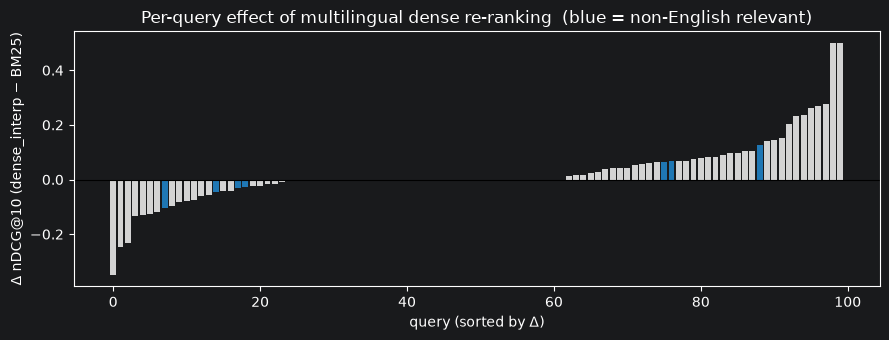

In [9]:
# per-query effect of the dense re-ranker, coloured by subset
d = (piv[best] - piv["BM25"]).sort_values()
order = d.index
colors = ["tab:blue" if piv.loc[q, "has_nonen_rel"] else "lightgray" for q in order]
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(range(len(d)), d.values, color=colors)
ax.axhline(0, c="black", lw=0.8)
ax.set_xlabel("query (sorted by Δ)"); ax.set_ylabel(f"Δ nDCG@10 ({best} − BM25)")
ax.set_title("Per-query effect of multilingual dense re-ranking  (blue = non-English relevant)")
plt.tight_layout(); plt.show()

## 8. Conclusions:

From this run (snapshot-1/train, 100 topics):

- H1 — supported. `BM25 >> dense (interp)` reaches nDCG@10 = 0.3167, the best of
  any system in this project (BM25-tuned 0.3050, BM25 0.2922). The gain over BM25 is
  +0.0245 and significant (paired t-test p = 0.039, Wilcoxon p = 0.038;
  38 wins / 25 losses). This is the positive result the lexical cross-lingual approach
  (NB05) could not reach.
- Blend, don't replace. Pure dense re-ranking hurts (0.2602 < BM25): the small
  e5 model alone is weaker than BM25's lexical signal on this scientific collection. Only
  the interpolation `0.5·BM25 + 0.5·dense` wins — lexical + semantic evidence are
  complementary.
- H2 — not supported (and instructive). The improvement is not concentrated on
  the cross-lingual topics. It is actually larger and significant on the English-only
  topics (Δ = +0.0267, p = 0.040) and tiny / non-significant on the 10 non-English-
  relevant topics (Δ = +0.0049, p = 0.82). So the dense re-ranker wins through general
  semantic matching (synonymy / paraphrase), not specifically cross-lingual recovery —
  the cross-lingual subset is too small (n = 10) and already English-covered to show an
  effect on these qrels.

Caveats for the paper:
1) `multilingual-e5-small` is the smallest e5; `-base`/`-large`
or a cross-encoder (`mmarco-mMiniLMv2`) would likely score higher — probably next step.
2) Re-ranking only the top-50 caps recall (Recall@1000 reflects 50 returned docs); for a
submission, re-rank a deeper pool and keep the BM25 tail.
3) Dense inference is the
runtime cost - it took for me roughly 4 min to run;
4) if we Re-run on our  group's own
qrels for the evaluation — they may contain more non-English relevant papers, which
is where H2 could still hold something.

The final twist analysed here: the gain is semantic, not (provably) cross-lingual on this judgment set.
